# Simple Potts Boundary Comparison from Saved Ground States

This notebook **never runs DMRG**. It indexes `data/ground_states/`, loads the saved MPS files matching one selected length, Hamiltonian, and set of boundary conditions, then performs the measurements, plots, and CFT fits.

We will:

1. Select saved Potts ground states with several exact boundary conditions.
2. Check the state probabilities at the restricted edges.
3. Compare their entanglement-entropy profiles.
4. Fit the leading open-chain CFT form and compare with the expected $c$.


## 0. Imports

The path setup lets the notebook work when Jupyter is launched either from `potts_model_project`, its `notebooks` folder, or the surrounding workspace.

In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import tenpy


def find_project_root():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "potts_model_project",
        cwd.parent,
        cwd.parent / "potts_model_project",
    ]
    for candidate in candidates:
        if (candidate / "potts_model" / "potts.py").is_file():
            return candidate
    raise RuntimeError("Could not locate the potts_model_project folder.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from potts_model.ground_state_io import load_ground_state, scan_ground_states

GROUND_STATE_DIR = PROJECT_ROOT / "data" / "ground_states"

print("Project root:", PROJECT_ROOT)
print("Ground-state folder:", GROUND_STATE_DIR)
print("TeNPy version:", tenpy.__version__)

Project root: /Users/Aditya/Desktop/Third Year Summer Project/potts_model_project
Ground-state folder: /Users/Aditya/Desktop/Third Year Summer Project/potts_model_project/data/ground_states
TeNPy version: 1.1.0


## 1. Hamiltonian convention

The saved states use the project's `PottsChain`, which implements the 3-state Potts Hamiltonian

$$
H=-J\sum_{\langle i,j\rangle}\sum_{\mu=1}^{3}P_i^\mu P_j^\mu-h\sum_iP_i,
$$

where

$$
P^\mu=|\mu\rangle\langle\mu|-\frac{I}{3},
\qquad
P=|\lambda_0\rangle\langle\lambda_0|-\frac{I}{3},
$$

and

$$
|\lambda_0\rangle=\frac{|1\rangle+|2\rangle+|3\rangle}{\sqrt{3}}.
$$

There is no `ClockChain` sign conversion in this notebook. For the ferromagnetic critical model discussed in the paper, $J=h$, and the expected central charge is $c=4/5$.

## 2. Select a saved run length and Hamiltonian

`R`, `J`, and `h` identify the saved physical runs to load. The default `R=52` matches the original comparison notebook. Change `R` to any length available for every selected boundary condition.

No DMRG accuracy parameters are needed here: their values are read from each saved file's metadata.

In [13]:
R = 80
J = -1.0
h = -1.0
C_TARGET = 4.0 / 5.0

print(f"R={R}, J={J}, h={h}")
print("Expected critical central charge:", C_TARGET)

R=80, J=-1.0, h=-1.0
Expected critical central charge: 0.8


## 3. Boundary conditions

The saved-run metadata uses the same boundary convention as `PottsChain`:

- `1`, `2`, `3`: retain only that state (fixed boundary).
- `-1`, `-2`, `-3`: remove that state and retain the other two (forbidden/partially fixed boundary).
- `"free"` or `None`: retain all three states.

These are exact Hilbert-space restrictions. There is no boundary-field strength to tune. Edit only `selected_case_labels` to compare a different subset.

In [14]:
all_boundary_cases = {
    "free|free": {"left": "free", "right": "free"},
    "1|1": {"left": 1, "right": 1},
    "1|2": {"left": 1, "right": 2},
    "1|3": {"left": 1, "right": 3},
    "1|-1": {"left": 1, "right": -1},
    "1|-2": {"left": 1, "right": -2},
    "1|free": {"left": 1, "right": "free"},
    "-1|-1": {"left": -1, "right": -1},
    "-1|-2": {"left": -1, "right": -2},
    "-1|free": {"left": -1, "right": "free"},
    "periodic": {
        "left": "free",
        "right": "free",
        "periodic": True,
        "order": "default",
    },
}

selected_case_labels = ["free|free", "1|1", "1|2", "-1|-1", "-1|-2"]

unknown_labels = set(selected_case_labels) - set(all_boundary_cases)
if unknown_labels:
    raise KeyError(f"Unknown boundary labels: {sorted(unknown_labels)}")

boundary_cases = {
    label: all_boundary_cases[label]
    for label in selected_case_labels
}

list(boundary_cases)

['free|free', '1|1', '1|2', '-1|-1', '-1|-2']

## 4. Index matching saved states

The scan reads only each file's small metadata header. Matching uses $R,J,h$, open/periodic geometry, both boundary restrictions, and MPS ordering—not filename parsing. Exactly one saved file must match each selected case.

In [15]:
def boundary_code(value):
    if value is None or value == "free":
        return 0
    return int(value)


def record_matches_case(record, case):
    if "index_error" in record:
        return False
    physics = record["physics"]
    return (
        int(physics["L"]) == R
        and np.isclose(float(physics["J"]), J, atol=1e-12, rtol=1e-12)
        and np.isclose(float(physics["h"]), h, atol=1e-12, rtol=1e-12)
        and bool(physics.get("periodic", False)) == bool(case.get("periodic", False))
        and str(physics.get("order", "default")) == str(case.get("order", "default"))
        and boundary_code(physics.get("left_boundary", 0)) == boundary_code(case["left"])
        and boundary_code(physics.get("right_boundary", 0)) == boundary_code(case["right"])
    )


all_records = scan_ground_states(GROUND_STATE_DIR)
invalid_records = [record for record in all_records if "index_error" in record]
if invalid_records:
    print("Warning: these files could not be indexed:")
    for record in invalid_records:
        print(" ", record["filename"], "->", record["index_error"])

records_by_label = {}
for label, case in boundary_cases.items():
    matches = [record for record in all_records if record_matches_case(record, case)]
    if not matches:
        raise FileNotFoundError(
            f"No saved state matches {label!r} at R={R}, J={J}, h={h}."
        )
    if len(matches) > 1:
        filenames = [record["filename"] for record in matches]
        raise RuntimeError(f"More than one saved file matches {label!r}: {filenames}")
    records_by_label[label] = matches[0]
    print(f"Matched {label:>10} <- {matches[0]['filename']}")

Matched  free|free <- potts_L0080_Jm1_hm1_open_Lfree_Rfree_default.h5
Matched        1|1 <- potts_L0080_Jm1_hm1_open_Lfix1_Rfix1_default.h5
Matched        1|2 <- potts_L0080_Jm1_hm1_open_Lfix1_Rfix2_default.h5
Matched      -1|-1 <- potts_L0080_Jm1_hm1_open_Lforbid1_Rforbid1_default.h5
Matched      -1|-2 <- potts_L0080_Jm1_hm1_open_Lforbid1_Rforbid2_default.h5


## 5. Load and measure all boundary cases

This replaces the original notebook's expensive DMRG cell. For each matched file, it loads the optimized MPS and stores the same analysis quantities:

- total energy and energy per physical site;
- entanglement entropy at every bond cut;
- the three state-probability profiles $\langle Q_1\rangle$, $\langle Q_2\rangle$, and $\langle Q_3\rangle$.

It also retains the saved numerical diagnostics and source filename.

In [16]:
results = {}

for label, case in boundary_cases.items():
    record = records_by_label[label]
    payload = load_ground_state(record["path"])
    psi = payload["psi"]
    metadata = payload["metadata"]
    physics = metadata["physics"]
    numerics = metadata["numerics"]

    if psi.L != R or int(physics["L"]) != R:
        raise RuntimeError(f"Loaded {label!r} with inconsistent length metadata.")

    state_probabilities = {
        state: np.real(psi.expectation_value(f"Q{state}"))
        for state in (1, 2, 3)
    }

    results[label] = {
        "label": label,
        "case": case,
        "periodic": bool(physics.get("periodic", False)),
        "psi": psi,
        "energy": float(numerics["energy"]),
        "energy_per_site": float(numerics["energy_per_site"]),
        "r": np.arange(1, R),
        "entropy": np.asarray(psi.entanglement_entropy(), dtype=float),
        "state_probabilities": state_probabilities,
        "chi": [int(value) for value in psi.chi],
        "chi_max_requested": int(numerics.get("chi_max_requested", max(psi.chi))),
        "sweeps": int(numerics.get("sweeps", 0)),
        "status": numerics.get("status", "unknown"),
        "source_file": record["filename"],
    }
    print(f"Loaded {label:>10}; bond dimensions: {psi.chi}")

print("Done. No DMRG was run.")

Loaded  free|free; bond dimensions: [3, 9, 27, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 61, 27, 9, 3]
Loaded        1|1; bond dimensions: [1, 3, 9, 27, 60, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 61, 27, 9, 3, 1]
Loaded        1|2; bond dimensions: [1, 3, 9, 27, 46, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70

## 6. Energies and exact boundary checks

For a fixed boundary `s`, $\langle Q_s\rangle$ at that edge must be exactly 1. For a forbidden boundary `-s`, $\langle Q_s\rangle$ must be exactly 0. Free boundaries have no single target probability.

In [17]:
def boundary_diagnostic(result, side):
    code = result["case"][side]
    if code in (None, "free", 0):
        return np.nan, "free"

    edge_index = 0 if side == "left" else -1
    state = abs(int(code))
    probability = result["state_probabilities"][state][edge_index]
    target = 1.0 if int(code) > 0 else 0.0
    return probability, f"target={target:.0f}"


print(f"{'boundary':>12} {'E/site':>14} {'left check':>22} {'right check':>22}")
print("-" * 76)

for label, result in results.items():
    left_value, left_target = boundary_diagnostic(result, "left")
    right_value, right_target = boundary_diagnostic(result, "right")
    left_text = "free" if np.isnan(left_value) else f"{left_value:.8f} ({left_target})"
    right_text = "free" if np.isnan(right_value) else f"{right_value:.8f} ({right_target})"
    print(
        f"{label:>12} {result['energy_per_site']:14.8f} "
        f"{left_text:>22} {right_text:>22}"
    )

    boundary         E/site             left check            right check
----------------------------------------------------------------------------
   free|free    -0.60244538                   free                   free
         1|1    -0.59471943  1.00000000 (target=1)  1.00000000 (target=1)
         1|2    -0.59486071  1.00000000 (target=1)  1.00000000 (target=1)
       -1|-1    -0.60137994  0.00000000 (target=0)  0.00000000 (target=0)
       -1|-2    -0.60151947  0.00000000 (target=0)  0.00000000 (target=0)


### Saved-run provenance

These diagnostics make the loaded calculation settings explicit without changing the comparison itself.

In [18]:
print(f"{'boundary':>12} {'chi cap':>9} {'max chi':>9} {'sweeps':>8} {'status':>18}")
print("-" * 62)
for label, result in results.items():
    print(
        f"{label:>12} {result['chi_max_requested']:9d} {max(result['chi']):9d} "
        f"{result['sweeps']:8d} {result['status']:>18}"
    )
    print(f"  source: {result['source_file']}")

    boundary   chi cap   max chi   sweeps             status
--------------------------------------------------------------
   free|free        70        70       11          converged
  source: potts_L0080_Jm1_hm1_open_Lfree_Rfree_default.h5
         1|1        70        70       14          converged
  source: potts_L0080_Jm1_hm1_open_Lfix1_Rfix1_default.h5
         1|2        70        70        6          converged
  source: potts_L0080_Jm1_hm1_open_Lfix1_Rfix2_default.h5
       -1|-1        70        70       12          converged
  source: potts_L0080_Jm1_hm1_open_Lforbid1_Rforbid1_default.h5
       -1|-2        70        70        6          converged
  source: potts_L0080_Jm1_hm1_open_Lforbid1_Rforbid2_default.h5


## 7. Inspect one state-probability profile

The operators `Q1`, `Q2`, and `Q3` are ordinary state projectors. Their expectation values sum to one on every site.

Maximum |sum_mu <Q_mu> - 1|: 2.220446049250313e-15


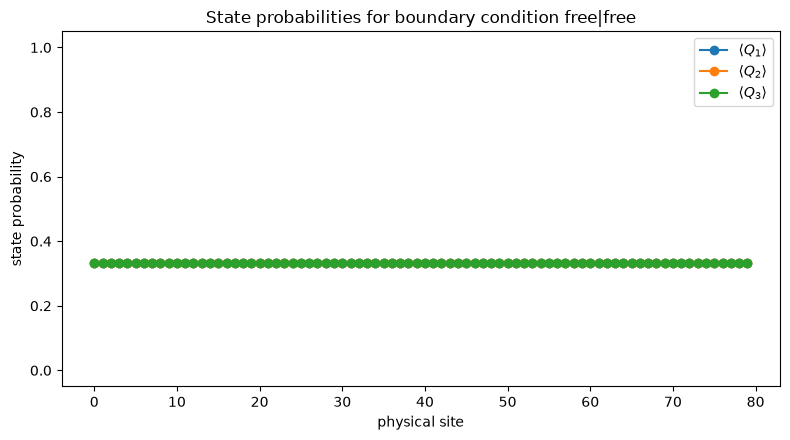

In [19]:
selected_case = "free|free"
selected = results[selected_case]
sites = np.arange(R)

plt.figure(figsize=(8, 4.5))
for state, probabilities in selected["state_probabilities"].items():
    plt.plot(sites, probabilities, "o-", label=fr"$\langle Q_{state}\rangle$")

probability_sum = sum(selected["state_probabilities"].values())
print("Maximum |sum_mu <Q_mu> - 1|:", np.max(np.abs(probability_sum - 1.0)))

plt.xlabel("physical site")
plt.ylabel("state probability")
plt.title(f"State probabilities for boundary condition {selected_case}")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()

## 8. Compare the entanglement profiles

$S(r,R)$ is the von Neumann entropy across the cut between physical sites $r-1$ and $r$. The first and last points can be strongly affected by the exact edge restrictions.

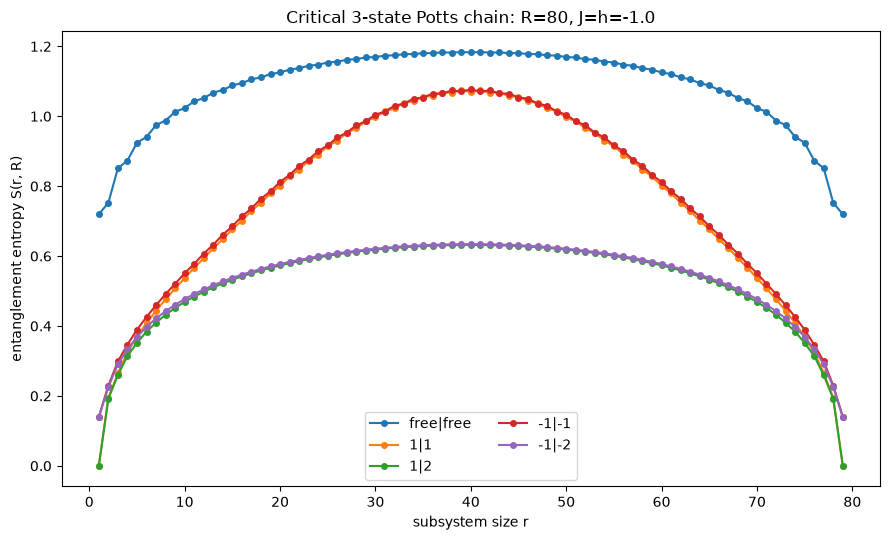

In [20]:
plt.figure(figsize=(9, 5.5))

for label, result in results.items():
    plt.plot(result["r"], result["entropy"], "o-", markersize=4, label=label)

plt.xlabel("subsystem size r")
plt.ylabel("entanglement entropy S(r, R)")
plt.title(f"Critical 3-state Potts chain: R={R}, J=h={J}")
plt.legend(ncols=2)
plt.tight_layout()

## 9. Open and periodic CFT fits

For a critical open chain, the leading smooth form is

$$
S(r,R)\approx\frac{c}{6}\log\left[\frac{2R}{\pi}\sin\left(\frac{\pi r}{R}\right)\right]+A.
$$

For a periodic chain, the corresponding form is

$$
S_{\mathrm{PBC}}(r,R)\approx\frac{c}{3}\log\left[\frac{R}{\pi}\sin\left(\frac{\pi r}{R}\right)\right]+A.
$$

The fitting code reads the geometry from the matched saved-state metadata. It uses $c_{\mathrm{fit}}=6\times\text{slope}$ for open chains and $c_{\mathrm{fit}}=3\times\text{slope}$ for the periodic chain. The expected value is $c=4/5$ for the ferromagnetic case and $c=1$ for the antiferromagnetic case.

This is only a rough fit: it ignores finite-size corrections and boundary-dependent corrections. We exclude several points near each edge.

In [21]:
def log_chord_length(r, R, periodic=False):
    prefactor = R / np.pi if periodic else 2.0 * R / np.pi
    return np.log(prefactor * np.sin(np.pi * r / R))


def fit_entropy_profile(r, entropy, R, periodic=False, edge_skip=3):
    x = log_chord_length(r, R, periodic=periodic)
    mask = (r > edge_skip) & (r < R - edge_skip)
    if np.count_nonzero(mask) < 2:
        raise ValueError("Not enough interior points for the requested fit.")

    slope, intercept = np.polyfit(x[mask], entropy[mask], deg=1)
    central_charge_factor = 3.0 if periodic else 6.0
    return {
        "x": x,
        "mask": mask,
        "geometry": "periodic" if periodic else "open",
        "slope": slope,
        "intercept": intercept,
        "fit": slope * x + intercept,
        "c_fit": central_charge_factor * slope,
    }


fits = {
    label: fit_entropy_profile(
        result["r"],
        result["entropy"],
        R,
        periodic=result["periodic"],
    )
    for label, result in results.items()
}

print(f"{'boundary':>12} {'geometry':>10} {'slope':>12} {'c_fit':>12} {'c_fit - 4/5':>16}")
print("-" * 68)
for label, fit_result in fits.items():
    print(
        f"{label:>12} {fit_result['geometry']:>10} "
        f"{fit_result['slope']:12.6f} "
        f"{fit_result['c_fit']:12.6f} "
        f"{fit_result['c_fit'] - C_TARGET:16.6f}"
    )

    boundary   geometry        slope        c_fit      c_fit - 4/5
--------------------------------------------------------------------
   free|free       open     0.163678     0.982065         0.182065
         1|1       open     0.441597     2.649581         1.849581
         1|2       open     0.170833     1.024997         0.224997
       -1|-1       open     0.431256     2.587536         1.787536
       -1|-2       open     0.162667     0.976001         0.176001


## 10. Individual fit plots

Each panel compares the saved DMRG entropy profile with the same leading smooth CFT fit used in the original notebook.

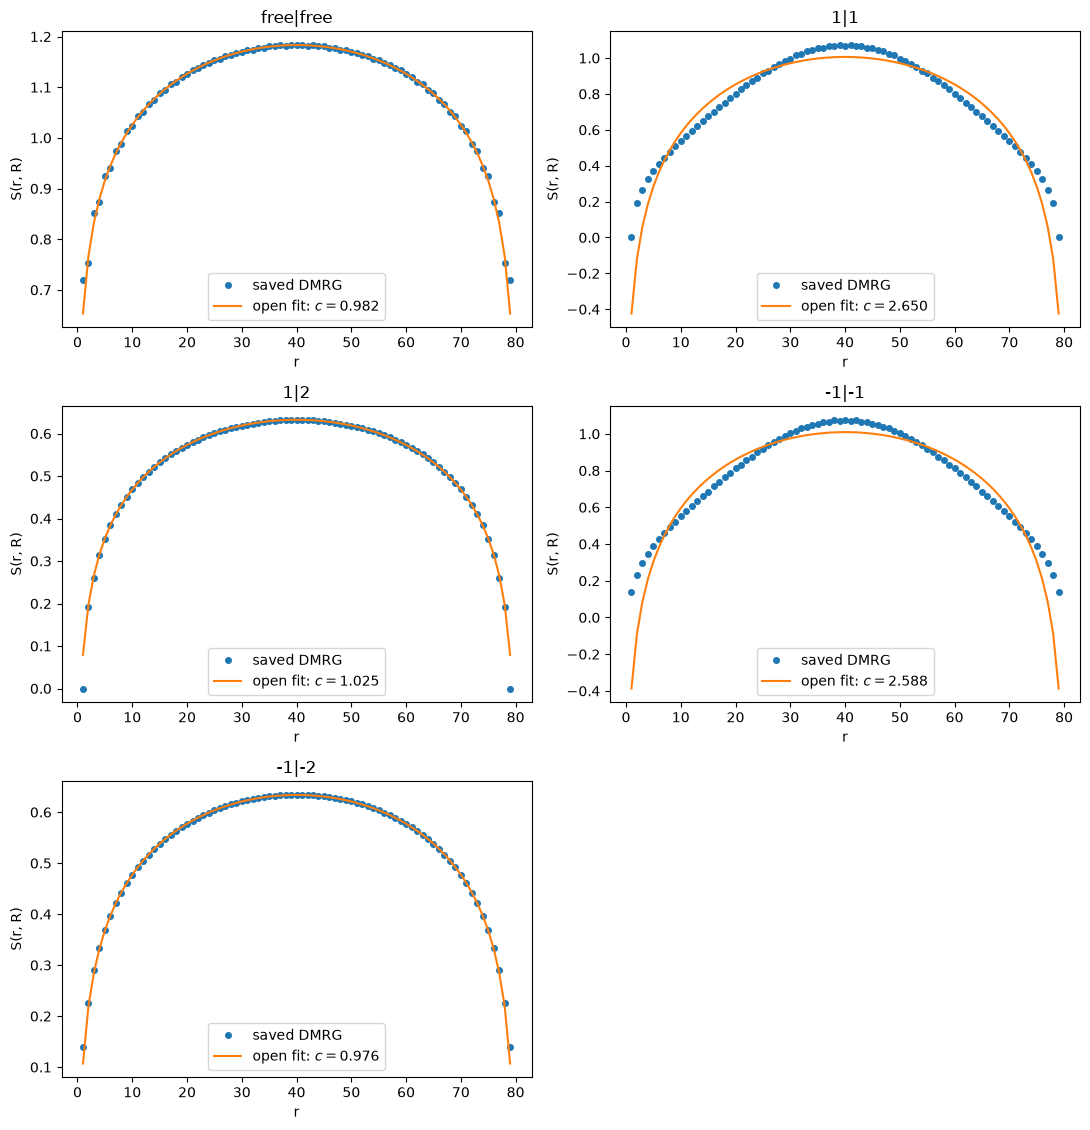

In [22]:
n_cases = len(results)
n_cols = 2
n_rows = int(np.ceil(n_cases / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 3.8 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for ax, (label, result) in zip(axes_flat, results.items()):
    fit_result = fits[label]
    ax.plot(result["r"], result["entropy"], "o", markersize=4, label="saved DMRG")
    ax.plot(
        result["r"],
        fit_result["fit"],
        "-",
        label=fr"{fit_result['geometry']} fit: $c={fit_result['c_fit']:.3f}$",
    )
    ax.set_title(label)
    ax.set_xlabel("r")
    ax.set_ylabel("S(r, R)")
    ax.legend()

for ax in axes_flat[n_cases:]:
    ax.axis("off")

plt.tight_layout()

## 11. Periodic-chain interpretation

If `periodic` is added to `selected_case_labels`, it is included in the plots and fitted with the periodic $c/3$ formula. The matched run must use `order="default"`, so each MPS cut corresponds to the physically contiguous block $\{0,\ldots,r-1\}$ and the entropy curve has its usual meaning.

Using `order="folded"` can make periodic DMRG more efficient, but then the MPS cuts describe folded, generally noncontiguous sets of physical sites. The resulting `psi.entanglement_entropy()` curve should not be interpreted as the standard contiguous-block $S(r,R)$.